In [1]:
# classifires

from scipy.stats import pearsonr
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
import joblib

In [2]:
# general purpose libraries

import time
from datetime import datetime
import numpy as np
from numpy import mean, isnan, asarray, polyfit
import pandas as pd
# import seaborn as sns
from sklearn import metrics
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelBinarizer, label_binarize
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit, cross_val_score, LeaveOneOut, cross_validate, cross_val_predict, GroupKFold
from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay, roc_auc_score, log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score, make_scorer
from sklearn.ensemble import VotingClassifier, StackingClassifier
from matplotlib.font_manager import FontProperties
from collections import Counter
# import rasterio as rio
#from imblearn.over_sampling import ADASYN

# Histogram display
import matplotlib.pyplot as plt
# import earthpy.plot as ep

In [3]:
path_SMOTE_data = r"..\..\Data\4.SMOTE\\"

In [4]:
print("Started...")
start_time = datetime.now()
num_samples = 1000000

tomato_healthy = pd.read_excel(path_SMOTE_data + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
tomato_unhealthy = pd.read_excel(path_SMOTE_data + "tomato_unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
capsicum = pd.read_excel(path_SMOTE_data + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
chilli = pd.read_excel(path_SMOTE_data + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
potato = pd.read_excel(path_SMOTE_data + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]                        
mulberry = pd.read_excel(path_SMOTE_data + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

# Data shapes
print("data_tomato_healthy:", tomato_healthy.shape)
print("data_tomato_unhealthy:", tomato_unhealthy.shape)
print("data_capsicum:", capsicum.shape)
print("data_chilli:", chilli.shape)
print("data_potato:", potato.shape)
print("data_mulberry:", mulberry.shape)

Started...
Data loading time is:> 0:04:59.113107
data_tomato_healthy: (2000, 944)
data_tomato_unhealthy: (2000, 944)
data_capsicum: (2000, 944)
data_chilli: (2000, 944)
data_potato: (2000, 944)
data_mulberry: (2000, 944)


In [5]:
# Shuffleing

tomato_healthy = tomato_healthy.sample(frac = 1)
tomato_healthy = tomato_healthy.sample(frac = 1)

tomato_unhealthy = tomato_unhealthy.sample(frac = 1)
tomato_unhealthy = tomato_unhealthy.sample(frac = 1)

chilli = chilli.sample(frac = 1)
chilli = chilli.sample(frac = 1)

capsicum = capsicum.sample(frac = 1)
capsicum = capsicum.sample(frac = 1)

potato = potato.sample(frac = 1)
potato = potato.sample(frac = 1)

mulberry = mulberry.sample(frac = 1)
mulberry = mulberry.sample(frac = 1)

In [6]:
# merging all dataframes into one 
data = pd.concat([tomato_healthy,capsicum,tomato_unhealthy,potato,chilli,mulberry], ignore_index=True, axis=0)
print("data:", data.shape)

data: (12000, 944)


In [7]:
df_final = data.copy() 
df_final = df_final.sample(frac = 1)
df_final = df_final.sample(frac = 1)
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
1703,tomato_healthy,0.039298,0.042118,0.044708,0.044736,0.041646,0.040599,0.044280,0.051163,0.047295,...,0.393910,0.391842,0.389497,0.386527,0.385245,0.385007,0.383616,0.382612,0.381659,0.379497
11689,mulberry,0.070520,0.068806,0.069169,0.072041,0.068807,0.069185,0.071209,0.070972,0.070495,...,0.481863,0.481375,0.479337,0.477970,0.476075,0.471613,0.469838,0.471020,0.469279,0.465384
9801,chilli,0.125646,0.118699,0.117435,0.123162,0.120826,0.120466,0.119807,0.116099,0.117501,...,0.644770,0.642821,0.640225,0.635354,0.632677,0.631876,0.630495,0.628953,0.627709,0.627360
3867,capsicum,0.122302,0.124826,0.127405,0.125007,0.125935,0.123695,0.121025,0.121740,0.123949,...,0.499522,0.497627,0.495987,0.495995,0.494265,0.490922,0.489248,0.487050,0.486269,0.488626
9474,chilli,0.164382,0.162876,0.162984,0.164150,0.168027,0.166401,0.164289,0.167189,0.167309,...,0.610974,0.607875,0.605469,0.603653,0.600849,0.596900,0.595019,0.593260,0.592160,0.594411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1984,tomato_healthy,0.036242,0.037172,0.039937,0.042982,0.039127,0.036202,0.034569,0.033494,0.037219,...,0.367554,0.364162,0.361409,0.358436,0.356269,0.355109,0.352483,0.348748,0.346622,0.344355
2608,capsicum,0.091433,0.093324,0.092164,0.089775,0.092414,0.090574,0.087603,0.088442,0.089766,...,0.432934,0.430162,0.428308,0.426834,0.425399,0.424146,0.423445,0.422913,0.422795,0.424792
6183,potato,0.088764,0.096689,0.097513,0.083401,0.085477,0.084587,0.084087,0.088546,0.084701,...,0.590497,0.586112,0.585021,0.583732,0.579834,0.578366,0.574708,0.560135,0.558012,0.575132
358,tomato_healthy,0.075944,0.083691,0.089047,0.084703,0.082467,0.085323,0.088108,0.086155,0.087300,...,0.456217,0.454297,0.452101,0.449197,0.447588,0.447007,0.445492,0.443590,0.442675,0.442287


In [9]:
# Removing odds
df_final = df_final[~df_final.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]

In [11]:
# visulization class distribution

def freq_visualize(df_final, title):
    print(df_final['label'].value_counts())
    labels = df_final['label'].values
    counter = Counter(labels) # counter object
    counter = dict(sorted(counter.items())) # converting counter obj. into dictionary
    x = list(counter.keys())
    y = list(counter.values())
    plt.rcParams.update({'font.size':8})
    fig = plt.figure(num=None, figsize=(10, 4), dpi=200, facecolor='w', edgecolor='red')
    plt.barh(x, y)
    plt.xlim(0, 3000)
    plt.ylabel("Labels", weight ='bold')
    plt.xlabel("Frequencies", weight ='bold')
    plt.title(title)
    plt.show()

tomato_healthy      2000
tomato_unhealthy    2000
capsicum            2000
chilli              2000
mulberry            2000
potato              2000
Name: label, dtype: int64


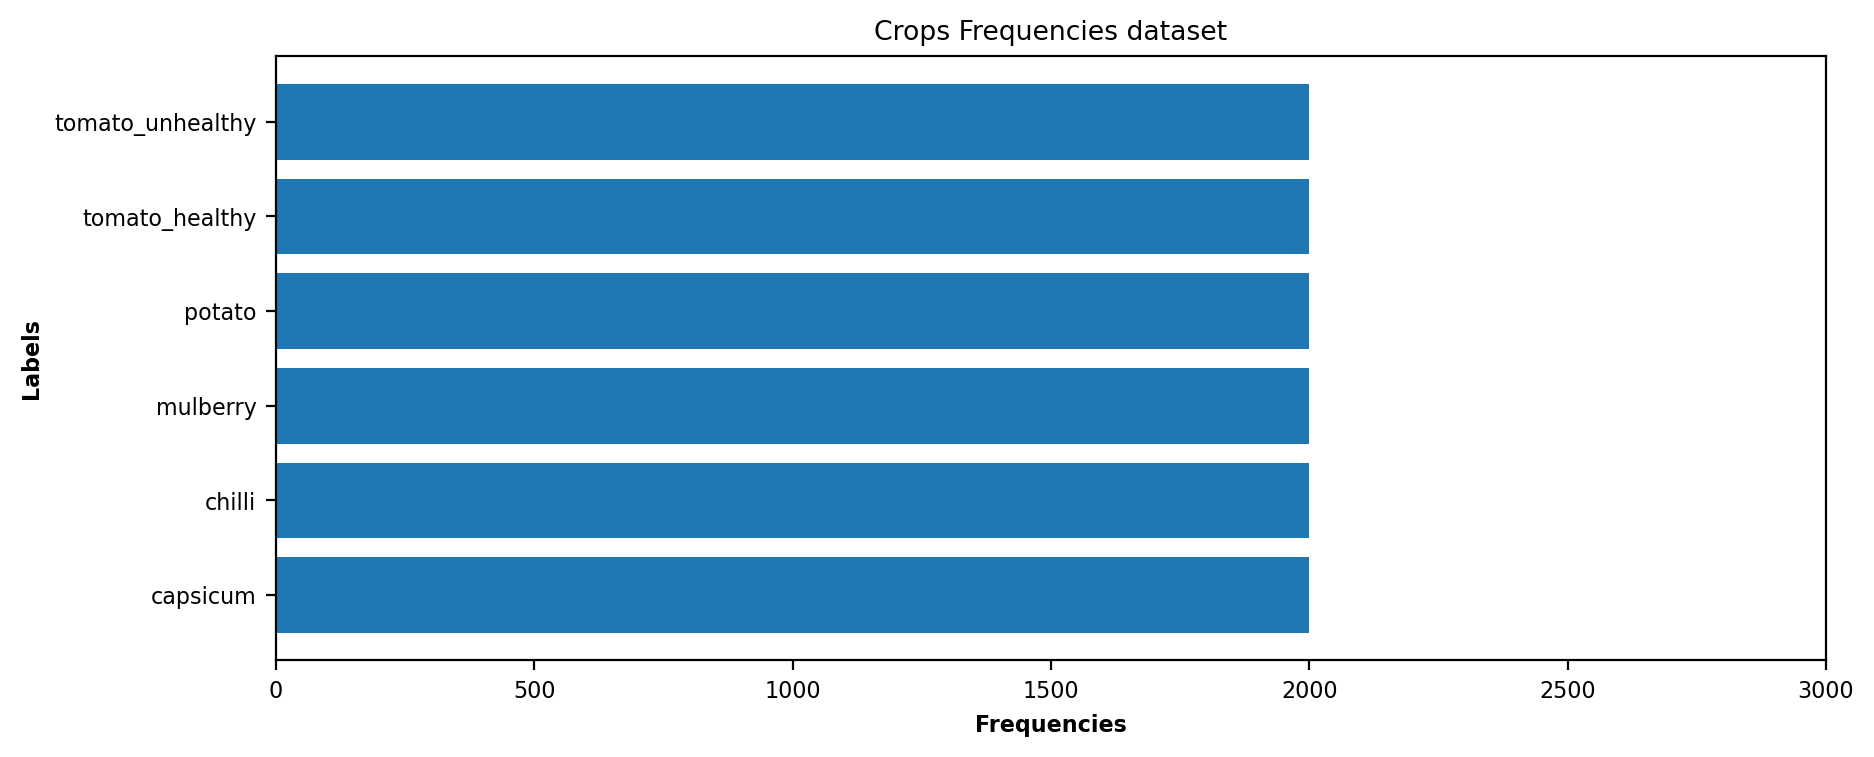

In [12]:
# calling the visualization function
freq_visualize(df_final, title="Crops Frequencies dataset")

In [13]:
# preparing trauing and testing datasets and label encoding
from sklearn import preprocessing

features = df_final.columns.difference(['label'])
X = df_final[features].values
y = df_final['label'].values

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)

print(type(X),"X:", X.shape)
print(type(y),"y:", y.shape)
print('\nunique values:\n', np.unique(y))

<class 'numpy.ndarray'> X: (12000, 943)
<class 'numpy.ndarray'> y: (12000,)

unique values:
 [0 1 2 3 4 5]


In [14]:
# label encoded class names
le = label_encoder
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5}


In [15]:
# data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100, stratify=y)

print(type(X_train), X_train.shape)
print(type(y_train), y_train.shape)
print(type(X_test), X_test.shape)
print(type(y_test), y_test.shape)

<class 'numpy.ndarray'> (8400, 943)
<class 'numpy.ndarray'> (8400,)
<class 'numpy.ndarray'> (3600, 943)
<class 'numpy.ndarray'> (3600,)


## Creating Cutom Ensemble model

In [23]:
# Listing the all models | commented some models due to predict_proba unavailability
def get_models():
    models = list()
    models.append(LogisticRegression(max_iter=1000))
    models.append(SGDClassifier(loss='log'))  # Set loss='log_log' for newer version
    models.append(GaussianNB())
    models.append(QuadraticDiscriminantAnalysis(reg_param=0.1))
    models.append(SVC(C=100, kernel='rbf', degree=3, gamma='auto', coef0=0.0, shrinking=True, probability=True, tol=0.001, cache_size=200, class_weight=None, verbose=0, max_iter=-1, decision_function_shape="ovr", random_state = 45)) # this
#     models.append(LinearSVC(dual=False)) # this
#     models.append(KNeighborsClassifier(n_neighbors=6))
#     models.append(RidgeClassifier()) # this
#     models.append(DecisionTreeClassifier())
#     models.append(AdaBoostClassifier(n_estimators=100, learning_rate=1))
#     models.append(RandomForestClassifier())
#     models.append(GradientBoostingClassifier())
    return models

# Function to create and train ensemble models
def create_ensemble(ensemble_type='soft_voting'): # soft_voting, stacking
    base_models = get_models()
    estimators = [(model.__class__.__name__.lower(), model) for model in base_models]
    
    if ensemble_type == 'soft_voting':
        # Create soft voting ensemble
        ensemble = VotingClassifier(estimators=estimators, voting='soft')
        print("Soft_voting is selected")
    elif ensemble_type == 'stacking':
        # Create stacking ensemble with LogisticRegression as meta-learner
        meta_learner = LogisticRegression(max_iter=1000)
        ensemble = StackingClassifier(estimators=estimators, final_estimator=meta_learner, cv=5)
        print("Stacking is selected")
    else:
        raise ValueError("ensemble_type must be 'soft_voting' or 'stacking'")
    return ensemble

In [24]:
# model training
model = create_ensemble(ensemble_type='soft_voting')
# -------------Start the training--------
tic = time.time()
model.fit(X_train, y_train)
toc = time.time()

training_time = time.strftime("%H:%M:%S", time.gmtime(toc-tic))
print("training time is {} in Hour:Minute:Seconds".format(training_time))


Soft_voting is selected


C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\discriminant_analysis.py:808: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


training time is 00:02:30 in Hour:Minute:Seconds


In [25]:
pred = model.predict(X_test)
# None, 'micro', 'macro', 'weighted', 'samples'
avg = 'macro'
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average=avg)
f1 = f1_score(y_test, pred, average=avg)
recall = recall_score(y_test, pred, average=avg)
mse = metrics.mean_squared_error(y_test, pred)
cnf = confusion_matrix(y_test, pred)
clf_refort = classification_report(y_test, pred)

results = {'CLF_Name': type(model).__name__, 'Accuracy': accuracy, 'Precision': precision, 'f1_score': f1, 'recall':recall, 'MSE':mse}
print(results, "\n")
print("Confusion Matrix: \n", cnf, "\n")
print("Classification Report: \n", clf_refort)

{'CLF_Name': 'VotingClassifier', 'Accuracy': 0.9544444444444444, 'Precision': 0.9546888609837242, 'f1_score': 0.9542857253363178, 'recall': 0.9544444444444444, 'MSE': 0.195} 

Confusion Matrix: 
 [[600   0   0   0   0   0]
 [  0 581   4   1  14   0]
 [  3   1 577   0  19   0]
 [ 13   4   7 537  39   0]
 [  2  23   9  19 541   6]
 [  0   0   0   0   0 600]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       600
           1       0.95      0.97      0.96       600
           2       0.97      0.96      0.96       600
           3       0.96      0.90      0.93       600
           4       0.88      0.90      0.89       600
           5       0.99      1.00      1.00       600

    accuracy                           0.95      3600
   macro avg       0.95      0.95      0.95      3600
weighted avg       0.95      0.95      0.95      3600



In [18]:
# saving the model
filename = '..\..\Models\Custom_ensemble_with_SMOTE_Data.sav'
joblib.dump(model,filename)

['..\\..\\Models\\Custom_ensemble_with_SMOTE_Data.sav']

# Testing in the same code file on original 20% data

In [27]:
path_real_data = r"..\..\Data\9.Split-data for revision\Test_20\\"

In [28]:
print("started...")
start_time = datetime.now()
num_samples = 1000000

data_tomato_healthy = pd.read_excel(path_real_data + "tomato_healthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_tomato_unhealthy = pd.read_excel(path_real_data + "tomato_Unhealthy.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]
data_potato = pd.read_excel(path_real_data + "potato.xlsx", sheet_name='Sheet1', engine='openpyxl')[:num_samples]                  
data_chilli = pd.read_excel(path_real_data + "chilli.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_capsicum = pd.read_excel(path_real_data + "capsicum.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]
data_mulberry = pd.read_excel(path_real_data + "mulberry.xlsx", sheet_name='Sheet1', engine='openpyxl').sample(frac = 1)[:num_samples]

end_time = datetime.now()
print('Data loading time is:> {}'.format(end_time - start_time))

print("tomato_healthy:", data_tomato_healthy.shape)
print("tomato_unhealthy:", data_tomato_unhealthy.shape)
print("data_potato:", data_potato.shape)
print("chilli:", data_chilli.shape)
print("capsicum:", data_capsicum.shape)
print("mulberry:", data_mulberry.shape)


# started...
# Data loading time is:> 0:01:13.131121
# tomato_healthy: (2672, 944)
# tomato_unhealthy: (274, 944)
# data_potato: (770, 944)
# chilli: (125, 944)
# capsicum: (75, 944)
# mulberry: (150, 944)

started...
Data loading time is:> 0:00:28.209328
tomato_healthy: (534, 944)
tomato_unhealthy: (155, 944)
data_potato: (154, 944)
chilli: (25, 944)
capsicum: (15, 944)
mulberry: (30, 944)


In [29]:
# merging all dataframes into one 
data = pd.concat([data_tomato_healthy,data_capsicum,data_tomato_unhealthy, data_potato, data_chilli, data_mulberry], ignore_index=True, axis=0)

In [30]:
df_final = data.copy()
df_final = df_final.sample(frac = 1)
df_final = df_final.sample(frac = 1)

# Removing the corrupt data
df_final = df_final[~df_final.isin([np.nan, np.inf, -np.inf]).any(axis = 1)]
df_final

,label,400,401,402,403,404,405,406,407,408,...,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342
756,potato,0.083200,0.091400,0.101277,0.100469,0.090100,0.087900,0.091300,0.093262,0.093300,...,0.486495,0.477284,0.476709,0.484730,0.480410,0.472398,0.469990,0.457628,0.453819,0.471248
842,potato,0.031311,0.031100,0.032400,0.032300,0.023300,0.023900,0.030938,0.035300,0.030600,...,0.284693,0.279648,0.275574,0.274225,0.270691,0.260740,0.261352,0.278094,0.271899,0.247148
326,tomato_healthy,1.200348,1.196654,1.193980,1.190943,1.186202,1.182215,1.178433,1.173943,1.169310,...,0.817078,0.810936,0.807630,0.803417,0.803136,0.808727,0.807475,0.803894,0.802455,0.795720
837,potato,0.030700,0.031768,0.035700,0.038200,0.034600,0.034100,0.035700,0.036100,0.037200,...,0.152431,0.151326,0.149317,0.146421,0.145457,0.145678,0.145092,0.145862,0.145686,0.143752
86,tomato_healthy,0.073200,0.076000,0.076600,0.075200,0.079047,0.079800,0.079300,0.080400,0.079600,...,0.517307,0.513816,0.511495,0.509871,0.508606,0.507496,0.506472,0.506944,0.505882,0.502195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,tomato_unhealthy,0.045566,0.046600,0.047800,0.047600,0.046900,0.046600,0.046900,0.047728,0.047910,...,0.140425,0.140085,0.138409,0.136213,0.135181,0.135029,0.133302,0.130888,0.129972,0.128239
697,tomato_unhealthy,0.023600,0.023300,0.022000,0.021300,0.020900,0.022400,0.022900,0.020700,0.022500,...,0.186915,0.179656,0.179050,0.183908,0.182872,0.182195,0.181696,0.175127,0.173806,0.181768
409,tomato_healthy,0.039100,0.039426,0.039281,0.039900,0.037600,0.039700,0.042700,0.042000,0.040600,...,0.303953,0.302769,0.300140,0.297622,0.295617,0.294366,0.292356,0.289229,0.288769,0.290394
831,potato,0.101124,0.100898,0.102191,0.104445,0.100821,0.102532,0.106449,0.107222,0.106957,...,0.581143,0.578307,0.575404,0.572120,0.570125,0.569460,0.567964,0.567293,0.565749,0.561798


tomato_healthy      534
tomato_unhealthy    155
potato              154
mulberry             30
chilli               25
capsicum             15
Name: label, dtype: int64


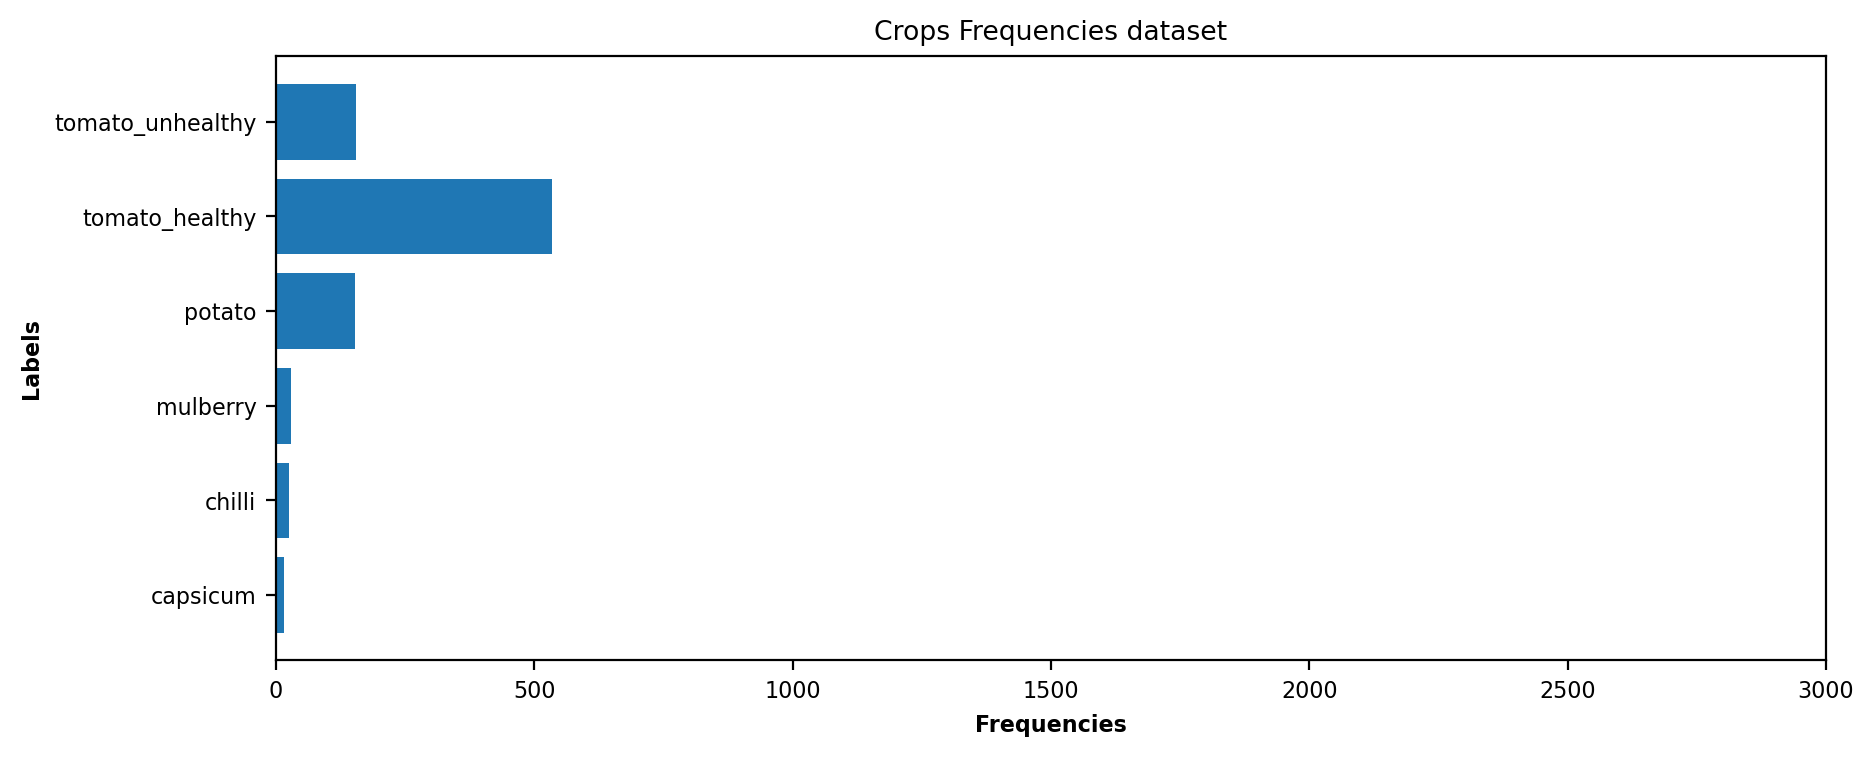

In [31]:
# calling the visualization function
freq_visualize(df_final, title="Crops Frequencies dataset")

In [32]:
# preparing trauing and testing datasets and label encoding
from sklearn import preprocessing

features = df_final.columns.difference(['label'])
X = df_final[features].values
y = df_final['label'].values

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)

print(type(X),"X:", X.shape)
print(type(y),"y:", y.shape)
print('\nunique values:\n', np.unique(y))

# label encoded class names
le = label_encoder
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

<class 'numpy.ndarray'> X: (913, 943)
<class 'numpy.ndarray'> y: (913,)

unique values:
 [0 1 2 3 4 5]
{'capsicum': 0, 'chilli': 1, 'mulberry': 2, 'potato': 3, 'tomato_healthy': 4, 'tomato_unhealthy': 5}


In [34]:
# Loading the model
# filename = r"..\..\Models\Custom_ensemble_with_SMOTE_Data.sav"
# model = joblib.load(filename)

pred = model.predict(X)
# None, 'micro', 'macro', 'weighted', 'samples'
avg = 'macro'
accuracy = accuracy_score(y, pred)
precision = precision_score(y, pred, average=avg)
f1 = f1_score(y, pred, average=avg)
recall = recall_score(y, pred, average=avg)
mse = metrics.mean_squared_error(y, pred)
cnf = confusion_matrix(y, pred)
clf_refort = classification_report(y, pred)

results = {'CLF_Name': type(model).__name__, 'Accuracy': "{:.2f}".format(accuracy), 'Precision': "{:.2f}".format(precision), 'F1_score': "{:.2f}".format(f1), 'Recall':"{:.2f}".format(recall), 'MSE':"{:.2f}".format(mse)}
print(results, "\n")
print("Confusion Matrix: \n", cnf, "\n")
print("Classification Report: \n", clf_refort)


# Old testing results
# {'CLF_Name': 'VotingClassifier', 'Accuracy': '0.70', 'Precision': '0.56', 'F1_score': '0.64', 'Recall': '0.90', 'MSE': '1.23'} 

# Confusion Matrix: 
#  [[  75    0    0    0    0    0]
#  [   0  119    1    0    0    5]
#  [   0    0  147    0    3    0]
#  [   4    6   30  675   14   41]
#  [  95  164  262  404 1561  186]
#  [   0    0    0    0    0  274]] 

# Classification Report: 
#                precision    recall  f1-score   support

#            0       0.43      1.00      0.60        75
#            1       0.41      0.95      0.57       125
#            2       0.33      0.98      0.50       150
#            3       0.63      0.88      0.73       770
#            4       0.99      0.58      0.73      2672
#            5       0.54      1.00      0.70       274

#     accuracy                           0.70      4066
#    macro avg       0.56      0.90      0.64      4066
# weighted avg       0.84      0.70      0.72      4066

{'CLF_Name': 'VotingClassifier', 'Accuracy': '0.11', 'Precision': '0.08', 'F1_score': '0.05', 'Recall': '0.18', 'MSE': '3.13'} 

Confusion Matrix: 
 [[  0   0  15   0   0   0]
 [  0   0  24   0   1   0]
 [  0   0  29   0   1   0]
 [  0   0 143   0  11   0]
 [  0   0 461   0  73   0]
 [  0   0  76   0  79   0]] 

Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.00      0.00      0.00        25
           2       0.04      0.97      0.07        30
           3       0.00      0.00      0.00       154
           4       0.44      0.14      0.21       534
           5       0.00      0.00      0.00       155

    accuracy                           0.11       913
   macro avg       0.08      0.18      0.05       913
weighted avg       0.26      0.11      0.12       913



C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\manoj\anaconda3\envs\tf\lib\site-pa